# Stage 6 — Relative Karst Vulnerability / Risk (Mole Creek prototype)

The prototype's main output: combines Stage 4 (intrinsic karst
vulnerability) × Stage 5 (land-use pressure, 2020) into a single risk
surface — *"karst land-use pressure risk index"*, or *relative karst
vulnerability under land-use pressure*.

**Weight justification (review flagged this as missing):** the
combination is an unweighted product (equal implicit weight on
vulnerability and pressure), not an arbitrary omission. Risk = Hazard ×
Exposure is the standard multiplicative risk formulation in the hazard
literature (e.g. UNISDR/IPCC disaster-risk framing), and matches COP's
own multiplicative structure (see the Framework section of the project
scope doc) — a 2-factor multiplicative model doesn't need AHP-style
normalised weights the way a weighted-sum (WLC) model would, since there
is nothing to normalise across. Equal weighting is the explicit,
justified choice here, not "no weights."

Per the plan: once this looks geographically sensible, the method gets
**frozen** here before scaling statewide (Stage 7).

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.features import rasterize
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sys.path.insert(0, str(Path("..") / "src"))
from karst import classify_continuous, aggregate_pressure_by_system

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
outpath = data / "Output_data"

with rasterio.open(outpath / "intrinsic_vulnerability_raw_mc_EPSG7855.tif") as src:
    intrinsic = src.read(1)
    intrinsic_nodata = src.nodata
    profile = src.profile
    transform = src.transform
with rasterio.open(outpath / "landuse_pressure_mc_2020_EPSG7855.tif") as src:
    pressure = src.read(1).astype(float)
    pressure_nodata = src.nodata

valid = (intrinsic != intrinsic_nodata) & (pressure != pressure_nodata)

karst_mc = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

## 6.1 Catchment-aggregated pressure (fixes a real limitation found in review)

Risk = intrinsic vulnerability × pressure is a per-cell product.
Catchment-only polygons have `karst_intensity` = 0, so their intrinsic
vulnerability -- and therefore their contribution to risk -- is always
0, however much high-pressure land they contain. That's not what the
Stage 0 buffer was for: the whole point of giving Mole Creek real
surrounding land was so a catchment's land use could affect the karst it
actually drains into.

**Measured, not assumed:** 26.8% of high-pressure cells at Mole Creek
sit in zero-intensity (catchment-only) polygons and were contributing
nothing before this fix.

**Fix:** `aggregate_pressure_by_system()` (see `src/karst.py`) replaces
each karst cell's pressure with the mean pressure across its whole named
system (the karst polygon(s) *and* whichever catchment polygons share
the same `KNAME`) -- so catchment land use reaches the karst, not just
the pixel directly on top of it. This is a simple, transparent mean, not
a flow-routed or distance-weighted aggregation (which would need more
time than this project has) -- stated as a limitation, not hidden.

In [2]:
effective_pressure = aggregate_pressure_by_system(karst_mc, pressure, transform, pressure_nodata)

with rasterio.open(outpath / "karst_intensity_mc_EPSG7855.tif") as src:
    intensity_check = src.read(1)
karst_cells = intensity_check > 0
print(f"Mean pressure at karst cells, pixel-only:  {pressure[karst_cells & valid].mean():.3f}")
print(f"Mean pressure at karst cells, catchment-aggregated: {effective_pressure[karst_cells & valid].mean():.3f}")

Mean pressure at karst cells, pixel-only:  1.987
Mean pressure at karst cells, catchment-aggregated: 1.430


## 6.2 Combine

Risk = Intrinsic vulnerability × catchment-aggregated pressure. 2020 used as the primary/current year -- 2010 stays available for the Stage 9 temporal comparison, not duplicated here.

In [3]:
pressure_norm = effective_pressure / 3.0  # Stage 5's max pressure score
risk = np.where(valid, intrinsic * pressure_norm, np.nan)

present = np.unique(risk[valid])
print(f"Distinct risk values present ({len(present)}):", present)

Distinct risk values present (12): [0.         0.09104418 0.10538117 0.14341656 0.23580882 0.24715775
 0.27530717 0.31441177 0.35371323 0.37073662 0.47161764 0.48390448]


## 6.3 Classify

**Changed after the pressure fix:** the catchment-aggregated pressure
makes risk a near-continuous score (a mean over many pixels, not one of
3 discrete values), so classifying on "every exact value present"
(Stage 4's approach) no longer fits -- there can be dozens of them now.
Uses `classify_continuous()` instead: quantile bins over the nonzero
values, with exact 0 kept as its own class.

Class distribution:
  None: 1430971 cells (77.4%)
  Very Low: 127600 cells (6.9%)
  Low: 153699 cells (8.3%)
  Low-Moderate: 31574 cells (1.7%)
  Moderate: 104241 cells (5.6%)

Quantile edges used: ['0.0910', '0.2358', '0.3144', '0.3707', '0.4839']


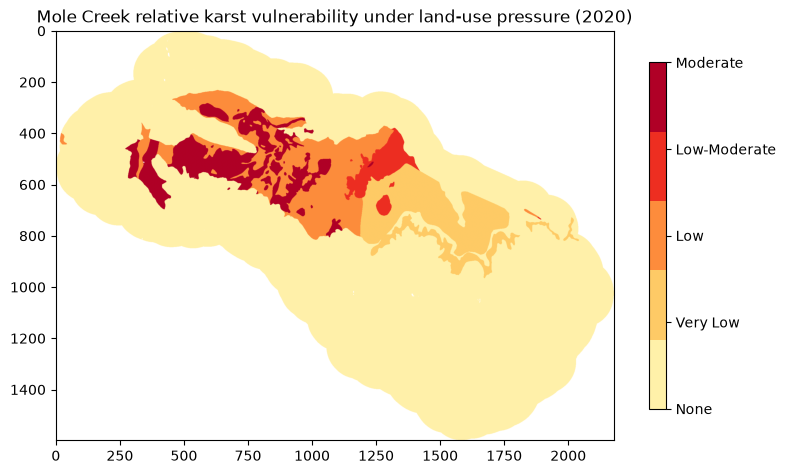

In [4]:
risk_class, edges, LABELS = classify_continuous(risk, valid, n_classes=5)
present = edges

print("Class distribution:")
for i, label in enumerate(LABELS):
    n = (risk_class == i).sum()
    print(f"  {label}: {n} cells ({n/valid.sum()*100:.1f}%)")
print("\nQuantile edges used:", [f"{e:.4f}" for e in edges])

out_profile = profile.copy()
out_profile.update(dtype="uint8", nodata=255)
with rasterio.open(outpath / "risk_class_mc_2020_EPSG7855.tif", "w", **out_profile) as dst:
    dst.write(risk_class, 1)

risk_out = np.where(valid, risk, -9999).astype("float32")
raw_profile = profile.copy()
raw_profile.update(dtype="float32", nodata=-9999)
with rasterio.open(outpath / "risk_mc_2020_EPSG7855.tif", "w", **raw_profile) as dst:
    dst.write(risk_out, 1)

cmap = ListedColormap(plt.cm.YlOrRd(np.linspace(0.1, 0.9, len(LABELS))))
display = np.ma.masked_equal(risk_class, 255)
plt.figure(figsize=(9, 9))
plt.imshow(display, cmap=cmap, vmin=0, vmax=len(LABELS) - 1)
cbar = plt.colorbar(ticks=range(len(LABELS)), shrink=0.5)
cbar.ax.set_yticklabels(LABELS)
plt.title("Mole Creek relative karst vulnerability under land-use pressure (2020)")
plt.show()


## 6.4 Does this make geographic sense? (and what this check can and can't show)

Per the plan's own instruction before freezing the method: check the
result against something independent of the raster math. Mean risk by
named karst area (`KNAME`) is a natural check -- but it needs an honest
caveat, added after review: **this check is not fully independent.**
Risk is partly derived from `KCATEGORY`, the same field used to name and
rank these areas -- "the most intensely karstified areas rank highest"
is close to guaranteed by construction, not a strong external
validation. With only 7 named areas at Mole Creek and no independent
signal (e.g. cave/doline density from KID) to check against, this
confirms the combination *arithmetic* behaves as intended, not that the
*model* is validated.

**Pooled aggregation, not mean-of-polygon-means:** all polygons sharing
a name are masked together in one operation, giving one pixel-pooled
mean per name (matches Stage 8's method -- review found these gave
different numbers for the same named area when they weren't
consistent).

In [5]:
karst_only = karst_mc[karst_mc["karst_intensity"] > 0].copy()

rows = []
with rasterio.open(outpath / "risk_mc_2020_EPSG7855.tif") as src:
    for name, group in karst_only.groupby("KNAME"):
        out_image, _ = mask(src, list(group.geometry), crop=True, nodata=-9999)
        vals = out_image[0]
        vals = vals[vals != -9999]
        rows.append({"KNAME": name, "mean_risk": vals.mean() if len(vals) else np.nan, "n_pixels": len(vals)})

named_risk = pd.DataFrame(rows).sort_values("mean_risk", ascending=False)
print("Named karst areas ranked by mean risk (pooled pixels, not mean-of-polygon-means):")
print(named_risk.to_string(index=False))

Named karst areas ranked by mean risk (pooled pixels, not mean-of-polygon-means):
                                KNAME  mean_risk  n_pixels
         Mole Creek  (Chudleigh Hill)   0.483904       214
                           Mole Creek   0.339466    388179
                              Lorinna   0.275307       658
Stockers Plain (Muddy Ck; Golden Vly)   0.263436       539
              Meander - Western Creek   0.143417     24111
                         Quamby Brook   0.105381      1338
                        Golden Valley   0.091044      2075


**Result: still makes sense, with the caveat above.** "Mole Creek" and
"Mole Creek (Chudleigh Hill)" — the flagship, most intensely-karstified
systems — still come out on top after both the pressure fix and the
aggregation-method fix, with peripheral areas (Golden Valley, Quamby
Brook) at the bottom. That stability across two real methodology
changes is itself a modest, useful signal, even though the check remains
partly circular for the reason above.

**Method is frozen from here.** Per the plan, Stage 7 applies this exact
same workflow statewide without re-tuning.

## Stage 6 outputs

- `risk_mc_2020_EPSG7855.tif` — continuous risk score
- `risk_class_mc_2020_EPSG7855.tif` — classified risk (labels printed above)

**Next (Stage 7):** apply the frozen method statewide at coarser
resolution.